## Best Optimization CV - Employer Bee Algo 2 + Onlooker Bee Algo 3

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()

features_size = gallstone_dataset.x_train.shape[1]
x_train = gallstone_dataset.x_train
x_test  = gallstone_dataset.x_test
y_train = gallstone_dataset.y_train
y_test  = gallstone_dataset.y_test

In [3]:
mod = "Grid_Optimization"

In [4]:
best_lambda_config = GlobalSetting.get_config_by_type(mod)
best_lambda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lambda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [5]:
abc_r_elm_cv  = ArtificialBeeColonyElmCV(
    features_size       = features_size,
    hidden_size         = best_lambda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lambda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_r_elm_cv.employed_bee_apply_algo3()
abc_r_elm_cv.init_algo3(initial_probability=0.05, final_probability=0.95)
abc_r_elm_cv.onlooker_bee_apply_algo2()

In [6]:
results_df , convergence_df , scout_df = abc_testing(abc_r_elm_cv, x_train, y_train, x_test, y_test)
results_df.describe()


Running simulation for Seed: 161...
Iteration 120 complete | Duration: 0.3004s | Scout Triggers: 1 | Best Fitness: 0.789267

Running simulation for Seed: 162...
Iteration 120 complete | Duration: 0.4117s | Scout Triggers: 0 | Best Fitness: 0.795577

Running simulation for Seed: 163...
Iteration 120 complete | Duration: 0.3136s | Scout Triggers: 0 | Best Fitness: 0.813586

Running simulation for Seed: 164...
Iteration 120 complete | Duration: 0.2889s | Scout Triggers: 1 | Best Fitness: 0.796509

Running simulation for Seed: 165...
Iteration 120 complete | Duration: 0.3259s | Scout Triggers: 1 | Best Fitness: 0.793811

Running simulation for Seed: 166...
Iteration 120 complete | Duration: 0.3271s | Scout Triggers: 0 | Best Fitness: 0.795414

Running simulation for Seed: 167...
Iteration 120 complete | Duration: 0.3441s | Scout Triggers: 3 | Best Fitness: 0.799893

Running simulation for Seed: 168...
Iteration 120 complete | Duration: 0.3441s | Scout Triggers: 1 | Best Fitness: 0.781407


,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.771354,0.789359,0.742708,0.758435,0.800000,0.763992,0.750790,0.771354,0.545234,175.500000
std,0.034449,0.040415,0.056669,0.040681,0.048273,0.038333,0.048301,0.034449,0.068603,8.803408
min,0.671875,0.689655,0.625000,0.657143,0.687500,0.655738,0.636943,0.671875,0.345271,161.000000
25%,0.750000,0.758621,0.718750,0.732781,0.781250,0.745763,0.725574,0.750000,0.507064,168.250000
50%,0.765625,0.796552,0.750000,0.757576,0.812500,0.766667,0.754717,0.765625,0.537856,175.500000
75%,0.792969,0.819775,0.781250,0.784598,0.843750,0.780853,0.784935,0.792969,0.587267,182.750000
max,0.843750,0.862069,0.875000,0.866667,0.875000,0.848485,0.864198,0.843750,0.688847,190.000000


In [7]:
results_df

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
0,0.765625,0.774194,0.75000,0.757576,0.78125,0.761905,0.754717,0.765625,0.531510,161
1,0.828125,0.862069,0.78125,0.800000,0.87500,0.819672,0.796178,0.828125,0.659153,162
2,0.750000,0.722222,0.81250,0.785714,0.68750,0.764706,0.792683,0.750000,0.503953,163
3,0.750000,0.833333,0.62500,0.700000,0.87500,0.714286,0.657895,0.750000,0.516398,164
4,0.812500,0.833333,0.78125,0.794118,0.84375,0.806452,0.791139,0.812500,0.626224,165
5,0.796875,0.787879,0.81250,0.806452,0.78125,0.800000,0.807453,0.796875,0.594040,166
6,0.781250,0.800000,0.75000,0.764706,0.81250,0.774194,0.759494,0.781250,0.563602,167
7,0.734375,0.777778,0.65625,0.702703,0.81250,0.711864,0.677419,0.734375,0.474579,168
8,0.812500,0.812500,0.81250,0.812500,0.81250,0.812500,0.812500,0.812500,0.625000,169
9,0.734375,0.727273,0.75000,0.741935,0.71875,0.738462,0.745342,0.734375,0.468979,170


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_MCC.png


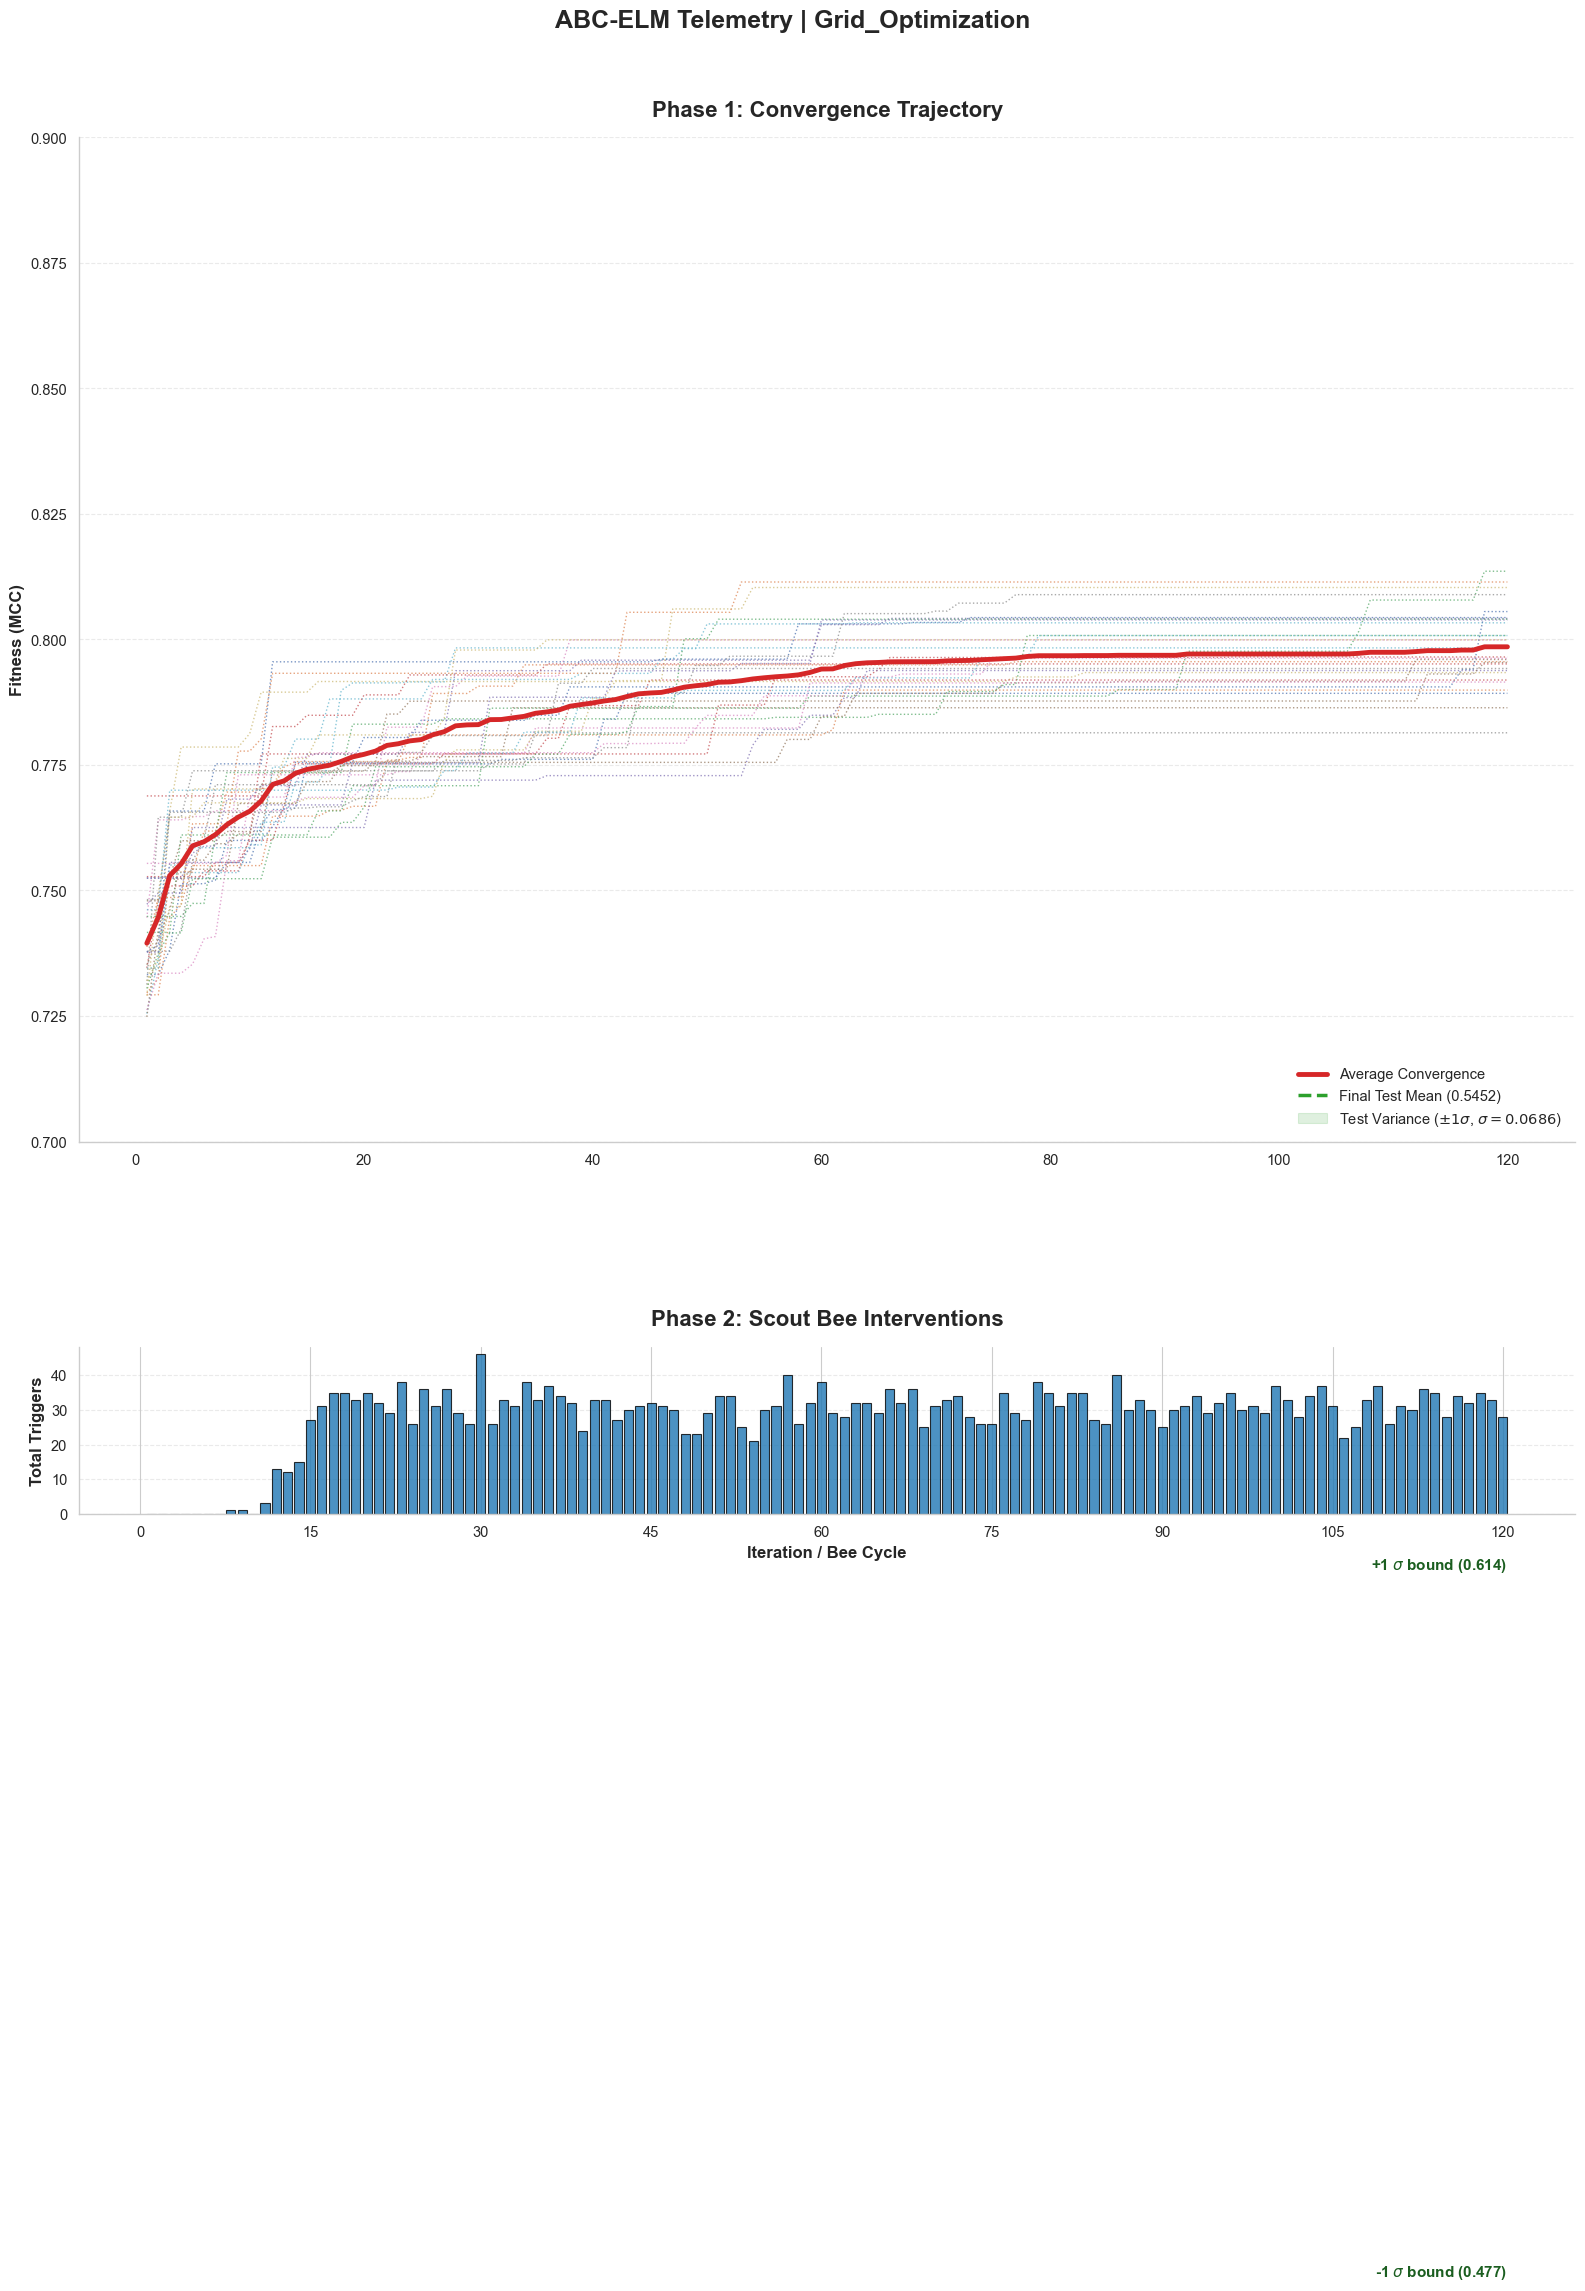

In [8]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,mod,results_df=results_df,is_final_record=True)

In [9]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")
GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')
GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Scout_History.csv
